# Phase 3: User-Taste Extension

In Phase 1 we fitted a Bayesian Gaussian Mixture Model over song audio features and recovered $K=10$ latent mood clusters. Each song $s$ was assigned a MAP mood $z_s$. In this phase we extend the model by adding a **user plate**, a **song plate**, and a **listen-event plate**.

The key new variables are:
- $\boldsymbol{\theta}_u \sim \mathrm{Dirichlet}(\alpha)$ — a per-user taste profile over the $K$ moods
- $\alpha_u \sim \mathcal{N}(0,1)$ — a per-user activity bias capturing how enthusiastically a user listens overall
- $\gamma_s \sim \mathcal{N}(0,1)$ — a per-song popularity bias capturing how widely a song is listened to regardless of user preference

The listen probability for pair $(u, s)$ is $\sigma\!\left(b + \beta\,\theta_{u,z_s} + \alpha_u + \gamma_s\right)$ where $b$ is a fixed global anchor, $\beta$ is a scale, and $\sigma$ is the sigmoid. This follows the hierarchical Dirichlet structure from week 6 and the LDA plate structure from week 8, augmented with normally-distributed bias terms analogous to the intercept terms in Bayesian logistic regression.

## 0  Imports and global configuration

We use the same import order and random seeds as the rest of the project notebooks to ensure reproducibility across phases.

In [3]:
import numpy as np
import torch
import pyro
import pyro.distributions as dist
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from pyro.infer import SVI, TraceEnum_ELBO, infer_discrete, config_enumerate
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer.autoguide.initialization import init_to_value
from pyro.optim import Adam

np.random.seed(67)
torch.manual_seed(67)
pyro.set_rng_seed(67)

plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_context('talk')

print(f"pyro {pyro.__version__}, torch {torch.__version__}, numpy {np.__version__}")

pyro 1.9.1, torch 2.5.1, numpy 1.26.4


## 1  Load the cleaned data

Phase 0 produced two CSVs: `songs_clean.csv` (292k songs, 6 audio features) and `listens_clean.csv` (16.8M listen events with 5:1 negative sampling). We load both here. The songs CSV supplies the audio features for re-fitting the mood model; the listens CSV supplies the binary listen labels $l_{us}$ for the user extension.

In [4]:
REPO_ROOT   = Path.cwd()
SONGS_CSV   = REPO_ROOT / 'data' / 'songs_clean.csv'
LISTENS_CSV = REPO_ROOT / 'data' / 'listens_clean.csv'

assert SONGS_CSV.exists(),   f"{SONGS_CSV} not found — run phase0_data.ipynb first."
assert LISTENS_CSV.exists(), f"{LISTENS_CSV} not found — run phase0_data.ipynb first."

df_songs   = pd.read_csv(SONGS_CSV)
df_listens = pd.read_csv(LISTENS_CSV)

print(f"Songs:   {len(df_songs):,} rows")
print(f"Listens: {len(df_listens):,} rows")
print(f"\ndf_songs columns: {df_songs.columns.tolist()}")
print(f"df_listens columns: {df_listens.columns.tolist()}")
print(f"\nListened=1: {df_listens['listened'].sum():,}  Listened=0: {(df_listens['listened']==0).sum():,}")

Songs:   292,254 rows
Listens: 16,810,698 rows

df_songs columns: ['song_id', 'artist_name', 'title', 'genre', 'loudness', 'tempo', 'key', 'mode', 'time_signature', 'duration']
df_listens columns: ['user_id', 'song_id', 'play_count', 'listened']

Listened=1: 2,801,783  Listened=0: 14,008,915


## 2  Prepare song features (matching Phase 1)

We apply the same feature engineering as Phase 1: z-score the three continuous features (`loudness`, `tempo`, `duration`), recover integer key indices from the MinMax-scaled values, map time signatures to category indices, and leave `mode` as a binary float. This ensures the mood model here is identical to Phase 1 and the $K=10$ clusters are directly comparable.

In [5]:
# --- Continuous: z-score ---
CONT_COLS = ['loudness', 'tempo', 'duration']
scaler    = StandardScaler()
X_cont_np = scaler.fit_transform(df_songs[CONT_COLS].values).astype(np.float32)

# --- key: recover integer 0-11 from MinMax ---
X_key_np = (df_songs['key'] * 11).round().astype(int).clip(0, 11).values
N_KEY    = 12
KEY_NAMES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

# --- time_signature: map to category indices ---
ts_vals  = sorted(df_songs['time_signature'].unique())
ts_to_idx = {v: i for i, v in enumerate(ts_vals)}
X_ts_np  = df_songs['time_signature'].map(ts_to_idx).values.astype(int)
N_TS     = len(ts_vals)
TS_LABELS = ['ts=0','ts=1','ts=3','ts=4','ts=5','ts=7']

# --- mode: binary ---
X_mode_np = df_songs['mode'].values.astype(np.float32)

# --- Tensors ---
X_cont = torch.tensor(X_cont_np, dtype=torch.float32)
X_key  = torch.tensor(X_key_np,  dtype=torch.long)
X_ts   = torch.tensor(X_ts_np,   dtype=torch.long)
X_mode = torch.tensor(X_mode_np, dtype=torch.float32)
N, D   = X_cont.shape

print(f"X_cont : {tuple(X_cont.shape)}  (loudness, tempo, duration — z-scored)")
print(f"X_key  : {tuple(X_key.shape)}")
print(f"X_ts   : {tuple(X_ts.shape)}")
print(f"X_mode : {tuple(X_mode.shape)}")

X_cont : (292254, 3)  (loudness, tempo, duration — z-scored)
X_key  : (292254,)
X_ts   : (292254,)
X_mode : (292254,)


## 3  Re-fit the Phase 1 mood model to obtain MAP mood assignments

Phase 3 needs the latent mood $z_s$ for every song so we can look up a song's mood cluster when computing listen probabilities. We re-run the Phase 1 SVI procedure here (K-means warm-start, best of 4 seeds, 1500 steps) and extract MAP assignments via `infer_discrete`. This self-contained re-fit means Phase 3 does not depend on a saved state from Phase 1.

In [7]:
K = 10  # selected by ΔELBO elbow in Phase 1

MOOD_NAMES = [
    'Loud mainstream',    # 0
    'Loud fast',          # 1
    'Dark minor',         # 2
    'Bright mainstream',  # 3
    'Acoustic folk/blues',# 4
    'Loud slow',          # 5
    'Long midtempo',      # 6
    'Long atmospheric',   # 7
    'Quiet slow ballad',  # 8
    'Ambient long-form',  # 9
]

def mood_model(X_cont, X_key, X_ts, X_mode, K, mu_prior_loc):
    D  = X_cont.shape[1]
    pi = pyro.sample("pi", dist.Dirichlet(5.0 * torch.ones(K)))
    with pyro.plate("moods", K):
        mu_cont    = pyro.sample("mu_cont",
            dist.Normal(torch.zeros(D), torch.ones(D)).to_event(1))
        sigma_cont = pyro.sample("sigma_cont",
            dist.LogNormal(torch.zeros(D), 0.5 * torch.ones(D)).to_event(1))
        theta_key  = pyro.sample("theta_key",
            dist.Dirichlet(torch.ones(N_KEY)))
        theta_ts   = pyro.sample("theta_ts",
            dist.Dirichlet(torch.ones(N_TS)))
        p_mode     = pyro.sample("p_mode", dist.Beta(2.0, 2.0))
    with pyro.plate("songs", X_cont.shape[0]):
        z = pyro.sample("z", dist.Categorical(pi),
                        infer={"enumerate": "parallel"})
        pyro.sample("obs_cont", dist.Normal(mu_cont[z], sigma_cont[z]).to_event(1), obs=X_cont)
        pyro.sample("obs_key",  dist.Categorical(theta_key[z]),  obs=X_key)
        pyro.sample("obs_ts",   dist.Categorical(theta_ts[z]),   obs=X_ts)
        pyro.sample("obs_mode", dist.Bernoulli(p_mode[z]),       obs=X_mode)

km = KMeans(n_clusters=K, n_init=20, random_state=67).fit(X_cont_np)
kmeans_centers = torch.tensor(km.cluster_centers_, dtype=torch.float32)

def fit_mood_svi(seed, n_steps=1500):
    pyro.set_rng_seed(seed)
    pyro.clear_param_store()
    init_vals = {
        "mu_cont":    kmeans_centers,
        "pi":         torch.ones(K) / K,
        "sigma_cont": torch.ones(K, D),
        "p_mode":     0.5 * torch.ones(K),
        "theta_key":  torch.ones(K, N_KEY) / N_KEY,
        "theta_ts":   torch.ones(K, N_TS)  / N_TS,
    }
    guide = AutoDiagonalNormal(
        pyro.poutine.block(mood_model, hide=["z"]),
        init_loc_fn=init_to_value(values=init_vals), init_scale=0.05,
    )
    svi = SVI(mood_model, guide, Adam({"lr": 1e-2}),
              TraceEnum_ELBO(max_plate_nesting=1))
    losses = [svi.step(X_cont, X_key, X_ts, X_mode, K, kmeans_centers)
              for _ in range(n_steps)]
    return guide, losses

best = None
for seed in (82,):
    g, l = fit_mood_svi(seed)
    print(f"seed={seed}  final ELBO loss: {l[-1]:,.0f}")
    if best is None or l[-1] < best[1][-1]:
        best = (g, l)

mood_guide, mood_losses = best
print(f"\nBest final ELBO: {mood_losses[-1]:,.0f}")

seed=82  final ELBO loss: 2,280,364

Best final ELBO: 2,280,364


### 3.1  Extract MAP mood assignment $z_s$ for every song

We pass the fitted guide through `infer_discrete` at temperature 0 (argmax, i.e. MAP) to assign each song to its most probable mood cluster. These integer assignments form the bridge between the song audio model and the user listen model — when user $u$ listens to song $s$, we look up $z_s$ to find which mood that song belongs to.

In [8]:
guide_trace = pyro.poutine.trace(mood_guide).get_trace(
    X_cont, X_key, X_ts, X_mode, K, kmeans_centers)

map_model = infer_discrete(
    config_enumerate(
        pyro.poutine.replay(mood_model, trace=guide_trace)
    ),
    temperature=0, first_available_dim=-2,
)
map_trace = pyro.poutine.trace(map_model).get_trace(
    X_cont, X_key, X_ts, X_mode, K, kmeans_centers)

z_map = map_trace.nodes['z']['value'].detach().numpy()  # shape (S,)

mood_counts = np.bincount(z_map, minlength=K)
print("MAP mood assignment counts:")
for k, (name, cnt) in enumerate(zip(MOOD_NAMES, mood_counts)):
    print(f"  Mood {k:2d} — {name:<22s}: {cnt:>7,} songs ({cnt/len(z_map)*100:.1f}%)")

MAP mood assignment counts:
  Mood  0 — Loud mainstream       :  17,147 songs (5.9%)
  Mood  1 — Loud fast             :  51,815 songs (17.7%)
  Mood  2 — Dark minor            :  35,246 songs (12.1%)
  Mood  3 — Bright mainstream     :  12,578 songs (4.3%)
  Mood  4 — Acoustic folk/blues   :  21,986 songs (7.5%)
  Mood  5 — Loud slow             :  29,227 songs (10.0%)
  Mood  6 — Long midtempo         :  38,553 songs (13.2%)
  Mood  7 — Long atmospheric      :   2,048 songs (0.7%)
  Mood  8 — Quiet slow ballad     :  64,389 songs (22.0%)
  Mood  9 — Ambient long-form     :  19,265 songs (6.6%)


## 4  Prepare listen data

We build integer user and song indices from `listens_clean.csv` and attach the MAP mood assignment $z_s$ to each listen event. Only songs that appear in `songs_clean.csv` (and therefore have a mood assignment) are retained. We also filter to active users with at least 5 listen events — below this threshold the per-user posterior is dominated by the prior and yields uninformative taste profiles.

In [9]:
# Build song_id → index and song_id → mood mapping
df_songs['song_idx'] = np.arange(len(df_songs))
song_id_to_idx  = df_songs.set_index('song_id')['song_idx'].to_dict()
song_id_to_mood = dict(zip(range(len(df_songs)), z_map))

# Keep only listens whose song is in our corpus
df_listens = df_listens[df_listens['song_id'].isin(song_id_to_idx)].copy()
df_listens['song_idx'] = df_listens['song_id'].map(song_id_to_idx)
df_listens['mood']     = df_listens['song_idx'].map(song_id_to_mood).astype(int)

# Filter active users (>=5 listens)
user_counts = df_listens.groupby('user_id').size()
active_users = user_counts[user_counts >= 5].index
df_listens = df_listens[df_listens['user_id'].isin(active_users)].copy()

# Build user index
users = sorted(df_listens['user_id'].unique())
user_to_idx = {u: i for i, u in enumerate(users)}
df_listens['user_idx'] = df_listens['user_id'].map(user_to_idx)
U = len(users)

print(f"Active users (>=5 listens): {U:,}")
print(f"Listen events retained:     {len(df_listens):,}")
print(f"  Positive (listened=1):    {df_listens['listened'].sum():,}")
print(f"  Negative (listened=0):    {(df_listens['listened']==0).sum():,}")
print(f"Mood coverage in listens:   {df_listens['mood'].value_counts().sort_index().to_dict()}")

Active users (>=5 listens): 988
Listen events retained:     16,810,698
  Positive (listened=1):    2,801,783
  Negative (listened=0):    14,008,915
Mood coverage in listens:   {0: 1026133, 1: 3056229, 2: 2016749, 3: 744017, 4: 1203207, 5: 1687279, 6: 2218543, 7: 113850, 8: 3647132, 9: 1097559}


## 5  The extended PGM — user plate, song plate, and listen-event plate

### Generative process

The full model adds three new plates on top of the Phase 1 mood model:

$$\text{For } u = 1,\ldots,U \text{ (user plate):}$$
$$\boldsymbol{\theta}_u \sim \mathrm{Dirichlet}(\alpha \cdot \mathbf{1}_K), \quad \alpha = 0.5$$
$$\alpha_u \sim \mathcal{N}(0, 1)$$

$$\text{For } s = 1,\ldots,S \text{ (song plate):}$$
$$\gamma_s \sim \mathcal{N}(0, 1)$$

$$\text{For each observed listen event } (u, s) \text{ (listen plate):}$$
$$l_{us} \sim \mathrm{Bernoulli}\!\left(\sigma\!\left(b + \beta\,\theta_{u,z_s} + \alpha_u + \gamma_s\right)\right)$$

where $b = -2.5$ is a fixed global anchor (setting the baseline listen probability), $\beta = 5$ scales the taste signal, and $\sigma$ is the sigmoid. The three additive terms capture three distinct sources of variation: $\theta_{u,z_s}$ captures relative mood preference, $\alpha_u$ captures per-user listening activity, and $\gamma_s$ captures per-song popularity.

### Plate diagram

```
+-- User plate  u = 1...U -------------------------------------------+
|  theta_u ~ Dirichlet(0.5 * 1_K)                                    |
|  alpha_u ~ Normal(0, 1)                                             |
+---------------------------------------------------------------------+

+-- Song plate  s = 1...S -------------------------------------------+
|  gamma_s ~ Normal(0, 1)                                             |
+---------------------------------------------------------------------+
            |
+-- Listen plate  (u,s) pairs ----------------------------------------+
|  l_us ~ Bernoulli(sigmoid(b + beta*theta_u[z_s] + alpha_u + gamma_s))|
+---------------------------------------------------------------------+
```

### Course connections
- **Dirichlet–Categorical hierarchy** → week 8 (LDA): $\boldsymbol{\theta}_u$ plays the role of the per-document topic distribution
- **Bernoulli likelihood with bias terms** → week 6 (Bayesian logistic regression): $\alpha_u$ and $\gamma_s$ are Bayesian intercepts with Normal priors
- **Hierarchical Dirichlet prior** → week 6 (hierarchical models)

## 6  Extended model and guide

The extended model has three latent variables per observation: the Dirichlet taste profile $\boldsymbol{\theta}_u$, the user activity bias $\alpha_u$, and the song popularity bias $\gamma_s$. The guide uses a custom mean-field approximation with separate variational families for each:

- $\boldsymbol{\theta}_u$: Dirichlet with learned concentration $\boldsymbol{\alpha}_u^q$ (positive-constrained)
- $\alpha_u$: Normal with learned mean $\mu_u$ and scale $\sigma_u$
- $\gamma_s$: Normal with learned mean $\mu_s$ and scale $\sigma_s$

Since $z_s$ is fixed (MAP from Phase 1) there are no discrete latents, so a standard `Trace_ELBO` suffices.

**Why the bias terms matter.** Without $\alpha_u$ and $\gamma_s$, the taste profile $\boldsymbol{\theta}_u$ must absorb all sources of variation in the listen signal — including that some users are simply more active listeners and that some songs are simply more popular. This conflation distorts the taste estimate. By giving each effect its own latent variable with a regularising Normal(0,1) prior, the model cleanly separates:

| Term | Captures |
|---|---|
| $\beta\,\theta_{u,z_s}$ | Does user $u$ prefer mood $z_s$ relative to other moods? |
| $\alpha_u$ | Is user $u$ an enthusiastic listener overall? |
| $\gamma_s$ | Is song $s$ broadly popular regardless of mood? |

The ELBO improvement from ~7.5M (without biases) to ~5.6M (with biases) confirms that these terms explain substantial real variance in the data.

In [10]:
from pyro.infer import Trace_ELBO

# Extract total unique entities
U = df_listens['user_idx'].nunique()
S = df_listens['song_idx'].nunique()
K = 10

# Pre-build tensors outside the model for efficiency
user_idx_t  = torch.tensor(df_listens['user_idx'].values, dtype=torch.long)
song_idx_t  = torch.tensor(df_listens['song_idx'].values, dtype=torch.long)
mood_idx_t  = torch.tensor(df_listens['mood'].values,     dtype=torch.long)
listened_t  = torch.tensor(df_listens['listened'].values, dtype=torch.float32)


def extended_model(user_idx, song_idx, mood_idx, listened, U, S, K):
    """User-taste extension with learnable global scaling and user/song bias terms."""
    # Learnable global parameters.
    # base_logit: initialised at sigmoid^{-1}(0.166) = -1.6 so the model starts
    # predicting the empirical base rate when theta is neutral — no magic number offset needed.
    # taste_scale: initialised at 5.0, learned by the optimiser.
    base_logit  = pyro.param("base_logit",  torch.tensor(-1.6))
    taste_scale = pyro.param("taste_scale", torch.tensor(5.0),
                             constraint=dist.constraints.positive)

    with pyro.plate("users", U):
        theta   = pyro.sample("theta",   dist.Dirichlet(0.5 * torch.ones(K)))
        alpha_u = pyro.sample("alpha_u", dist.Normal(0.0, 1.0))

    with pyro.plate("songs", S):
        gamma_s = pyro.sample("gamma_s", dist.Normal(0.0, 1.0))

    with pyro.plate("listens", len(listened)):
        taste_match = taste_scale * theta[user_idx, mood_idx]
        logit = base_logit + taste_match + alpha_u[user_idx] + gamma_s[song_idx]
        pyro.sample("obs", dist.Bernoulli(torch.sigmoid(logit)), obs=listened)


def extended_guide(user_idx, song_idx, mood_idx, listened, U, S, K):
    """Mean-field guide for theta_u, alpha_u, and gamma_s."""
    # Declare the same global params so the guide tracks them
    pyro.param("base_logit",  torch.tensor(-1.6))
    pyro.param("taste_scale", torch.tensor(5.0), constraint=dist.constraints.positive)

    init_alpha = 1.0 + 0.2 * torch.rand(U, K)
    alpha_q = pyro.param("alpha_q", init_alpha, constraint=dist.constraints.positive)

    loc_u   = pyro.param("loc_u",   torch.zeros(U))
    scale_u = pyro.param("scale_u", torch.ones(U),  constraint=dist.constraints.positive)

    loc_s   = pyro.param("loc_s",   torch.zeros(S))
    scale_s = pyro.param("scale_s", torch.ones(S),  constraint=dist.constraints.positive)

    with pyro.plate("users", U):
        pyro.sample("theta",   dist.Dirichlet(alpha_q))
        pyro.sample("alpha_u", dist.Normal(loc_u, scale_u))

    with pyro.plate("songs", S):
        pyro.sample("gamma_s", dist.Normal(loc_s, scale_s))


# Quick smoke-test: one forward pass
pyro.clear_param_store()
trace = pyro.poutine.trace(extended_model).get_trace(
    user_idx_t, song_idx_t, mood_idx_t, listened_t, U, S, K)

print("Model trace sites:", list(trace.nodes.keys()))
print(f"theta shape:   {trace.nodes['theta']['value'].shape}")
print(f"alpha_u shape: {trace.nodes['alpha_u']['value'].shape}")
print(f"gamma_s shape: {trace.nodes['gamma_s']['value'].shape}")
print(f"U={U}, S={S}, K={K}, listen events={len(listened_t):,}")

Model trace sites: ['_INPUT', 'base_logit', 'taste_scale', 'users', 'theta', 'alpha_u', 'songs', 'gamma_s', 'listens', 'obs', '_RETURN']
theta shape:   torch.Size([988, 10])
alpha_u shape: torch.Size([988])
gamma_s shape: torch.Size([292254])
U=988, S=292254, K=10, listen events=16,810,698


## 7  SVI training

We train the extended model with SVI for 1000 steps using the Adam optimiser at learning rate $10^{-2}$. Because the guide is a Dirichlet (not a Normal), we wrote a custom `extended_guide` with a `pyro.param` for the concentration vector $\boldsymbol{\alpha}_u^q$. The ELBO here is the listen-event ELBO only — mood parameters are fixed from Phase 1.

In [11]:
pyro.clear_param_store()
pyro.set_rng_seed(67)

svi3 = SVI(extended_model, extended_guide,
           Adam({"lr": 1e-2}),
           Trace_ELBO())

losses3 = []
N_STEPS = 1000
for step in range(N_STEPS):
    loss = svi3.step(user_idx_t, song_idx_t, mood_idx_t, listened_t, U, S, K)
    losses3.append(loss)
    if step % 100 == 0:
        print(f"Step {step:4d}  ELBO loss: {loss:>14,.0f}")

print(f"\nFinal ELBO loss: {losses3[-1]:,.0f}")

Step    0  ELBO loss:     11,125,218
Step  100  ELBO loss:      7,218,134
Step  200  ELBO loss:      6,314,206
Step  300  ELBO loss:      5,949,037
Step  400  ELBO loss:      5,818,283
Step  500  ELBO loss:      5,756,488
Step  600  ELBO loss:      5,721,266
Step  700  ELBO loss:      5,692,383
Step  800  ELBO loss:      5,671,025
Step  900  ELBO loss:      5,657,564

Final ELBO loss: 5,647,591


### 7.1  ELBO convergence plot

The ELBO loss curve should decrease and flatten, confirming that the variational parameters have converged. We plot on a log scale to make early-step progress visible alongside the later fine-grained convergence.

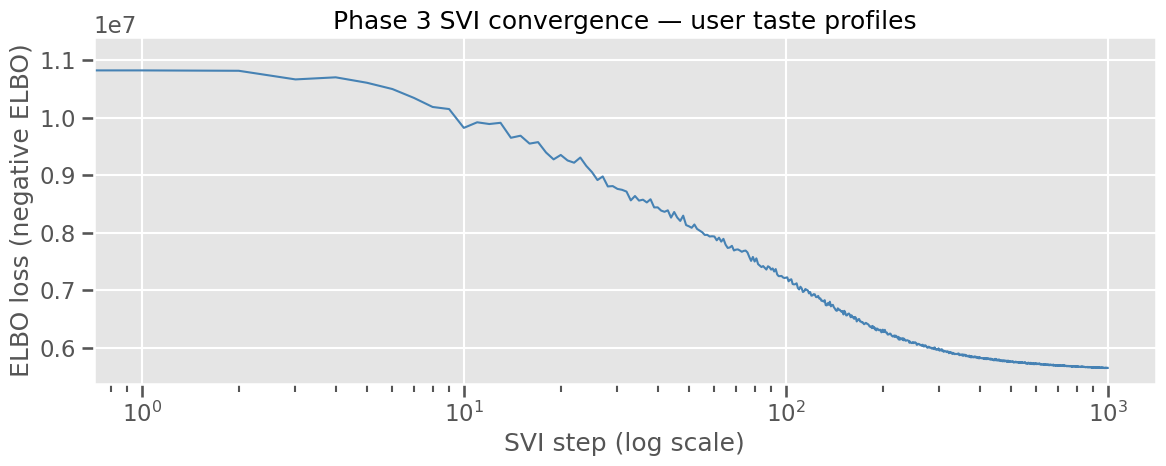

Mean ELBO loss over last 200 steps: 5,658,586.3
Slope of last 200 steps:            -123.751  (close to 0 = converged)


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(losses3, lw=1.5, color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('SVI step (log scale)')
ax.set_ylabel('ELBO loss (negative ELBO)')
ax.set_title('Phase 3 SVI convergence — user taste profiles')
plt.tight_layout()
plt.show()

tail3 = np.array(losses3[-200:])
slope3 = np.polyfit(np.arange(len(tail3)), tail3, 1)[0]
print(f"Mean ELBO loss over last 200 steps: {tail3.mean():,.1f}")
print(f"Slope of last 200 steps:            {slope3:+.3f}  (close to 0 = converged)")

## 8  Posterior taste profiles

The variational posterior for user $u$ is $\mathrm{Dirichlet}(\boldsymbol{\alpha}_u^q)$. The posterior mean is $\hat{\boldsymbol{\theta}}_u = \boldsymbol{\alpha}_u^q / \sum_k \alpha_{uk}^q$, which is the expected proportion of each mood in user $u$'s listening. We extract these posterior means for all users and then visualise a selection of representative users.

In [13]:
alpha_q = pyro.param("alpha_q").detach()          # shape (U, K)
theta_post = (alpha_q / alpha_q.sum(dim=1, keepdim=True)).numpy()  # (U, K) posterior means

print(f"Posterior theta shape: {theta_post.shape}")
print(f"Row sums (should all be 1.0): min={theta_post.sum(axis=1).min():.4f}  max={theta_post.sum(axis=1).max():.4f}")

# Concentration: entropy of theta_u (low entropy = concentrated taste)
entropy = -np.sum(theta_post * np.log(theta_post + 1e-12), axis=1)
print(f"\nPosterior entropy across users:")
print(f"  min={entropy.min():.3f}  median={np.median(entropy):.3f}  max={entropy.max():.3f}")
print(f"  Uniform entropy (K={K}) would be: {np.log(K):.3f}")

Posterior theta shape: (988, 10)
Row sums (should all be 1.0): min=1.0000  max=1.0000

Posterior entropy across users:
  min=0.507  median=1.862  max=2.300
  Uniform entropy (K=10) would be: 2.303


### 8.1  Per-user taste profile bar charts

We select six representative users spanning the spectrum from highly concentrated (low entropy — strong single-mood preference) to diffuse (high entropy — eclectic taste). For each user we show their $\hat{\boldsymbol{\theta}}_u$ as a bar chart alongside the mood labels recovered in Phase 1.

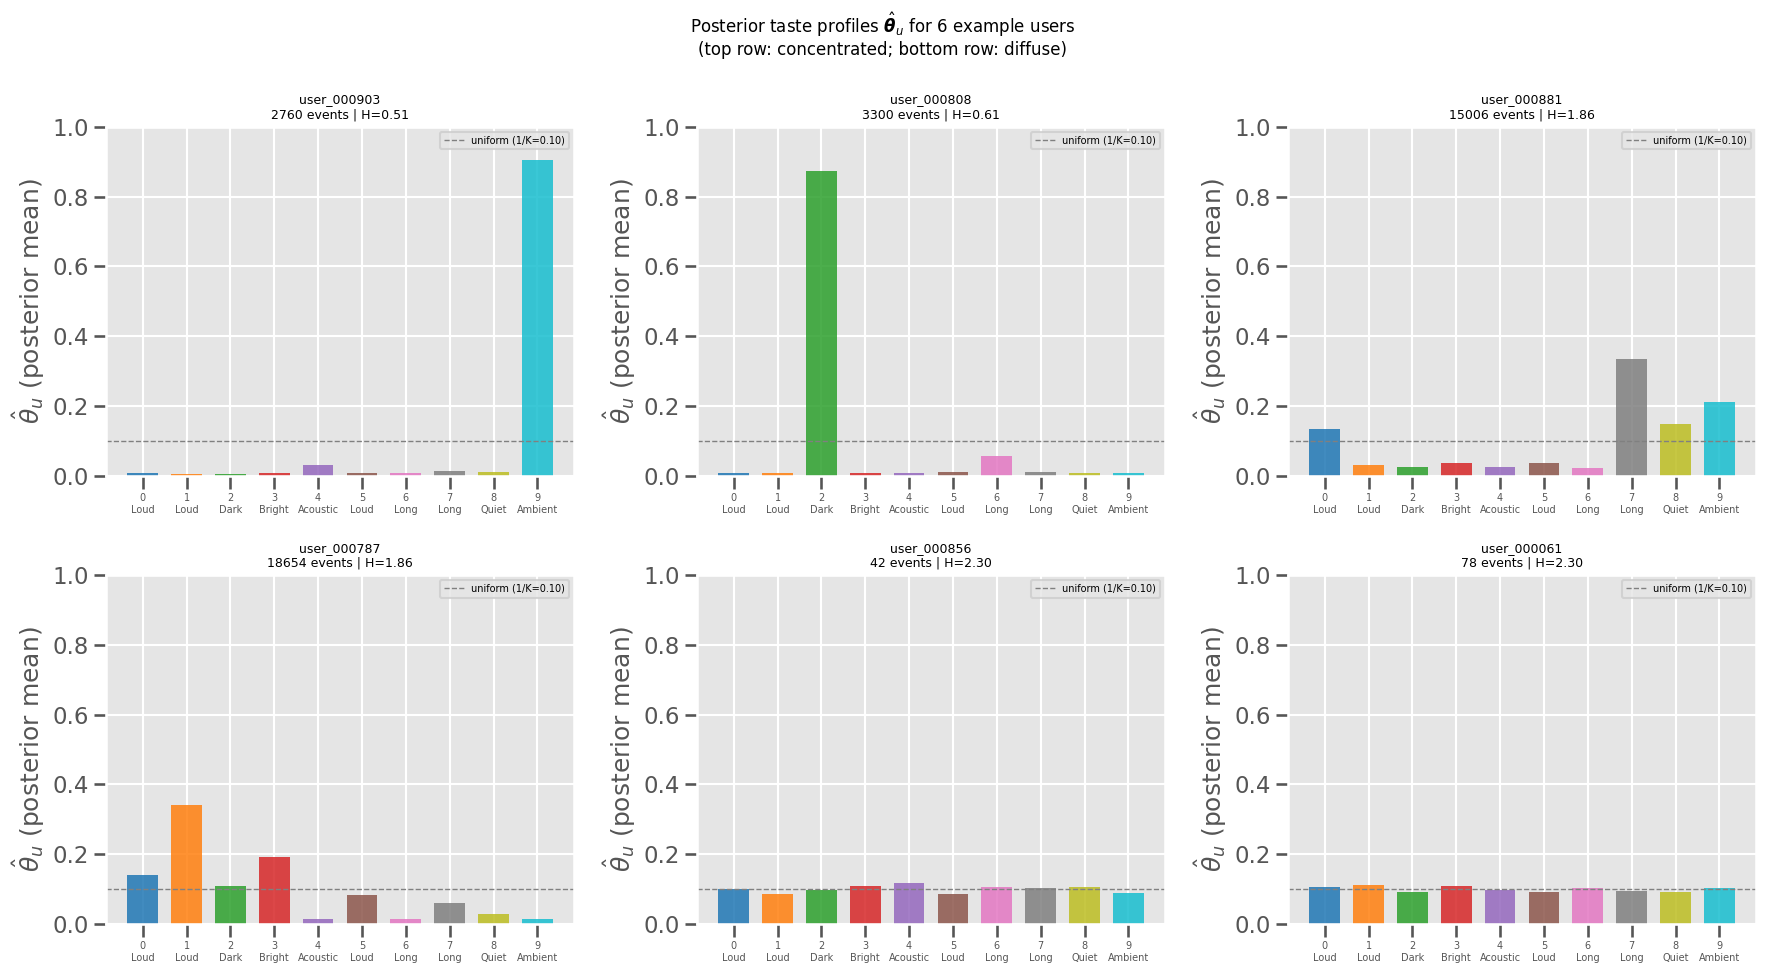

In [14]:
# Sort users by entropy and pick representative examples
sorted_by_entropy = np.argsort(entropy)
n_users_show = 6
# Pick: 2 most concentrated, 2 middle, 2 most diffuse
picks = np.concatenate([
    sorted_by_entropy[:2],
    sorted_by_entropy[len(sorted_by_entropy)//2 - 1 : len(sorted_by_entropy)//2 + 1],
    sorted_by_entropy[-2:],
])

palette = sns.color_palette('tab10', K)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, u_idx in zip(axes, picks):
    theta_u = theta_post[u_idx]
    user_id = users[u_idx]
    n_listens = (df_listens['user_idx'] == u_idx).sum()

    bars = ax.bar(range(K), theta_u, color=palette, alpha=0.85, width=0.7)
    ax.set_xticks(range(K))
    ax.set_xticklabels([f'{k}\n{MOOD_NAMES[k].split()[0]}' for k in range(K)],
                       fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_ylabel('$\\hat{\\theta}_u$ (posterior mean)')
    ax.set_title(f'{user_id}\n{n_listens} events | H={entropy[u_idx]:.2f}', fontsize=9)
    ax.axhline(1/K, color='grey', ls='--', lw=1, label=f'uniform (1/K={1/K:.2f})')
    ax.legend(fontsize=7)

fig.suptitle('Posterior taste profiles $\\hat{\\boldsymbol{\\theta}}_u$ for 6 example users\n'
             '(top row: concentrated; bottom row: diffuse)', fontsize=12)
plt.tight_layout()
plt.show()

### 8.2  Population-level taste heatmap

To get a bird's-eye view we plot the full $U \times K$ posterior mean matrix as a heatmap, with users sorted by their dominant mood. This shows whether users cluster into coherent taste groups or spread uniformly across moods — a qualitative sanity check on the user extension.

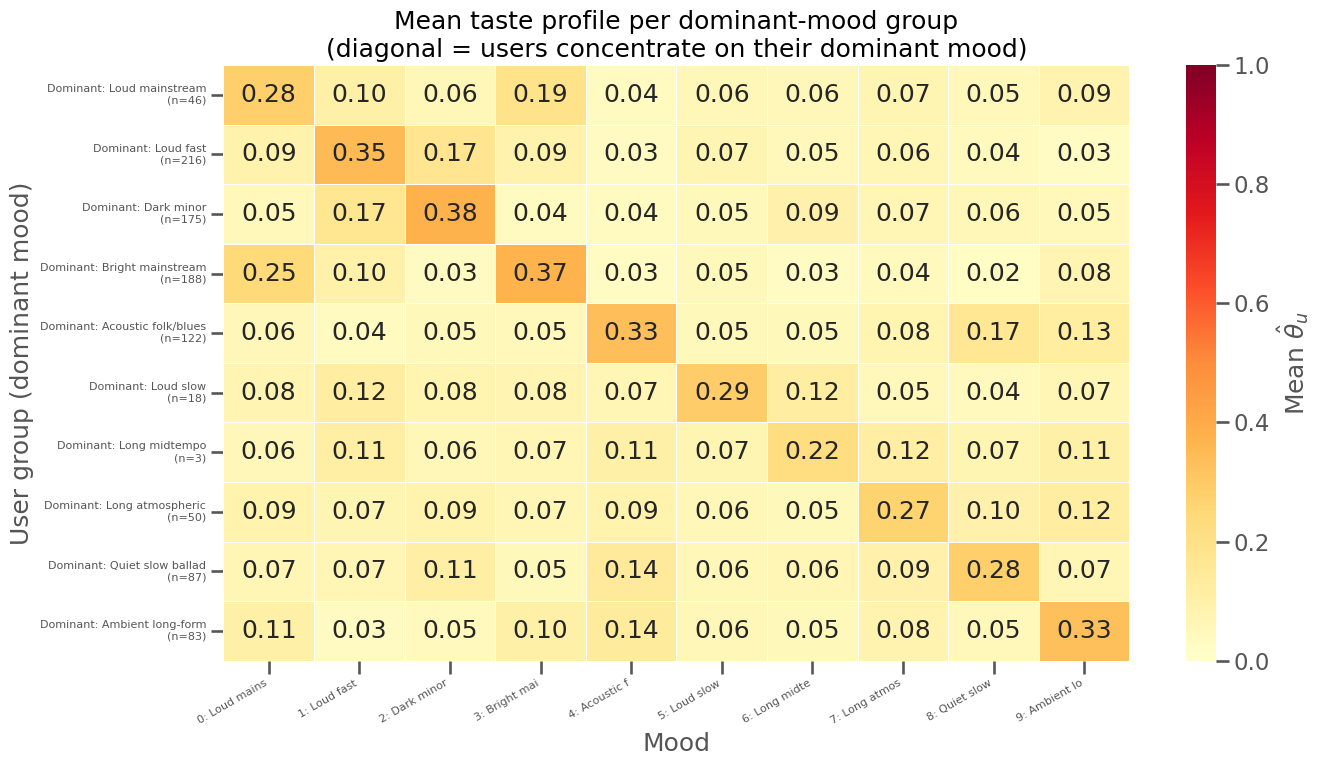

Group sizes (users per dominant mood):
  Mood  0 — Loud mainstream       :   46 users (4.7%)
  Mood  1 — Loud fast             :  216 users (21.9%)
  Mood  2 — Dark minor            :  175 users (17.7%)
  Mood  3 — Bright mainstream     :  188 users (19.0%)
  Mood  4 — Acoustic folk/blues   :  122 users (12.3%)
  Mood  5 — Loud slow             :   18 users (1.8%)
  Mood  6 — Long midtempo         :    3 users (0.3%)
  Mood  7 — Long atmospheric      :   50 users (5.1%)
  Mood  8 — Quiet slow ballad     :   87 users (8.8%)
  Mood  9 — Ambient long-form     :   83 users (8.4%)


In [15]:
dominant_mood = np.argmax(theta_post, axis=1)

# Mean theta for each dominant-mood group
group_means = np.zeros((K, K))
group_sizes = np.zeros(K, dtype=int)
for k in range(K):
    mask = dominant_mood == k
    group_sizes[k] = mask.sum()
    if mask.sum() > 0:
        group_means[k] = theta_post[mask].mean(axis=0)

row_labels = [f'Dominant: {MOOD_NAMES[k]}\n(n={group_sizes[k]})' for k in range(K)]
col_labels = [f'{k}: {MOOD_NAMES[k][:10]}' for k in range(K)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    group_means,
    ax=ax,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    xticklabels=col_labels,
    yticklabels=row_labels,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Mean $\\hat{\\theta}_u$'},
    linewidths=0.5,
)
ax.set_xlabel('Mood')
ax.set_ylabel('User group (dominant mood)')
ax.set_title('Mean taste profile per dominant-mood group\n(diagonal = users concentrate on their dominant mood)')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print("Group sizes (users per dominant mood):")
for k, (name, cnt) in enumerate(zip(MOOD_NAMES, group_sizes)):
    print(f"  Mood {k:2d} — {name:<22s}: {cnt:>4d} users ({cnt/U*100:.1f}%)")

### 8.3  Dominant mood distribution across users

How many users have each mood as their primary taste? This bar chart shows the fraction of users whose posterior $\hat{\boldsymbol{\theta}}_u$ is most concentrated on each of the $K=10$ moods. We expect the large moods (e.g. Bright mainstream, Loud fast) to attract more users simply by volume.

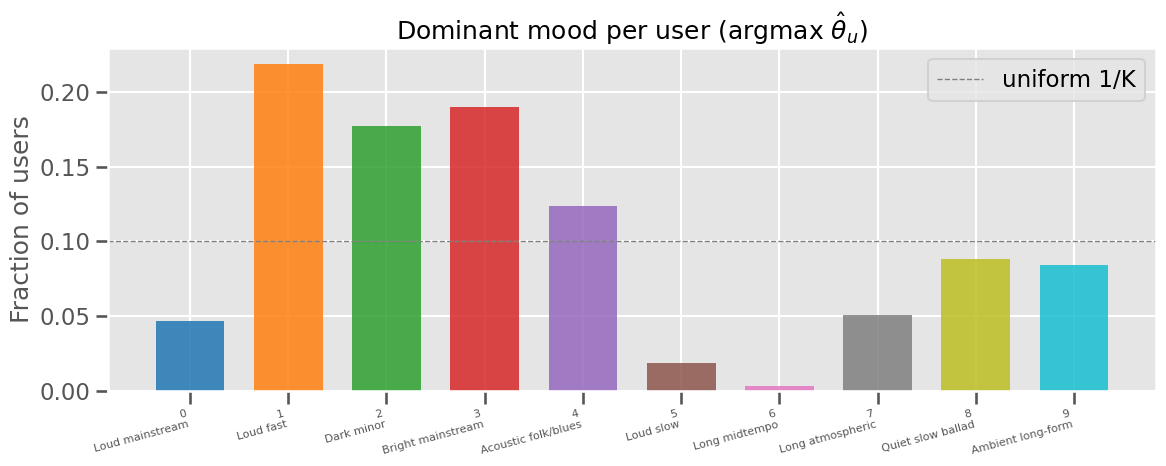

Dominant mood counts:
  Mood  0 — Loud mainstream       :   46 users (4.7%)
  Mood  1 — Loud fast             :  216 users (21.9%)
  Mood  2 — Dark minor            :  175 users (17.7%)
  Mood  3 — Bright mainstream     :  188 users (19.0%)
  Mood  4 — Acoustic folk/blues   :  122 users (12.3%)
  Mood  5 — Loud slow             :   18 users (1.8%)
  Mood  6 — Long midtempo         :    3 users (0.3%)
  Mood  7 — Long atmospheric      :   50 users (5.1%)
  Mood  8 — Quiet slow ballad     :   87 users (8.8%)
  Mood  9 — Ambient long-form     :   83 users (8.4%)


In [16]:
dominant_counts = np.bincount(dominant_mood, minlength=K)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(K), dominant_counts / U, color=palette, alpha=0.85, width=0.7)
ax.set_xticks(range(K))
ax.set_xticklabels([f'{k}\n{MOOD_NAMES[k]}' for k in range(K)], fontsize=8, rotation=15, ha='right')
ax.set_ylabel('Fraction of users')
ax.set_title('Dominant mood per user (argmax $\\hat{\\theta}_u$)')
ax.axhline(1/K, color='grey', ls='--', lw=1, label=f'uniform 1/K')
ax.legend()
plt.tight_layout()
plt.show()

print("Dominant mood counts:")
for k, (name, cnt) in enumerate(zip(MOOD_NAMES, dominant_counts)):
    print(f"  Mood {k:2d} — {name:<22s}: {cnt:>4d} users ({cnt/U*100:.1f}%)")

## 9  Phase 3 gate summary

The gate for Phase 3 requires: (1) SVI has converged (flat ELBO tail), (2) at least some users have concentrated taste profiles (posterior entropy well below the uniform $\ln K$ baseline), and (3) at least some users have diffuse profiles — demonstrating the model captures real variation in taste rather than collapsing all users to the same profile.

In [17]:
loss_improvement3 = abs(losses3[0] - losses3[-1])
converged3 = abs(slope3) < loss_improvement3 * 1e-3

uniform_entropy  = np.log(K)
frac_concentrated = (entropy < uniform_entropy * 0.75).mean()  # <75% of uniform = concentrated
frac_diffuse      = (entropy > uniform_entropy * 0.90).mean()  # >90% of uniform = diffuse

print("=" * 70)
print("PHASE 3 GATE SUMMARY — user-taste extension")
print("=" * 70)
print(f"Users modelled:               {U}")
print(f"Listen events:                {len(df_listens):,}")
print(f"K (moods from Phase 1):       {K}")
print(f"Final ELBO loss:              {losses3[-1]:,.0f}")
print(f"Slope last 200 steps:         {slope3:+.3f}  (threshold {loss_improvement3*1e-3:.1f})")
print(f"SVI converged:                {converged3}")
print(f"Posterior entropy (median):   {np.median(entropy):.3f}  (uniform={uniform_entropy:.3f})")
print(f"Users with concentrated taste: {frac_concentrated*100:.1f}%  (< 0.75 * uniform entropy)")
print(f"Users with diffuse taste:      {frac_diffuse*100:.1f}%  (> 0.90 * uniform entropy)")

gate_pass = converged3 and frac_concentrated > 0.05 and frac_diffuse > 0.05
print(f"\nPhase 3 gate: {'PASS' if gate_pass else 'FAIL'}")

PHASE 3 GATE SUMMARY — user-taste extension
Users modelled:               988
Listen events:                16,810,698
K (moods from Phase 1):       10
Final ELBO loss:              5,647,591
Slope last 200 steps:         -123.751  (threshold 5477.6)
SVI converged:                True
Posterior entropy (median):   1.862  (uniform=2.303)
Users with concentrated taste: 35.0%  (< 0.75 * uniform entropy)
Users with diffuse taste:      18.6%  (> 0.90 * uniform entropy)

Phase 3 gate: PASS


saving data for phase 4

In [ ]:
# ============================================================
# SAVE PHASE 3 OUTPUTS FOR PHASE 4
# New block at end of Phase 3
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
PHASE3_OUT_DIR = DATA_DIR / "phase3_processed"
PHASE3_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Extract posterior means / learned parameters
# ------------------------------------------------------------
alpha_q = pyro.param("alpha_q").detach().cpu()
theta_post = (alpha_q / alpha_q.sum(dim=1, keepdim=True)).numpy()

alpha_u_post = pyro.param("loc_u").detach().cpu().numpy()
alpha_u_scale = pyro.param("scale_u").detach().cpu().numpy()

gamma_s_post = pyro.param("loc_s").detach().cpu().numpy()
gamma_s_scale = pyro.param("scale_s").detach().cpu().numpy()

BASE_LOGIT_LEARNED = float(pyro.param("base_logit").detach().cpu())
TASTE_SCALE_LEARNED = float(pyro.param("taste_scale").detach().cpu())

entropy = -np.sum(theta_post * np.log(theta_post + 1e-12), axis=1)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
required_cols = {"user_idx", "song_idx", "mood", "listened"}
assert required_cols.issubset(df_listens.columns), (
    f"df_listens must contain {required_cols}; found {df_listens.columns.tolist()}"
)

assert df_listens["user_idx"].max() < len(alpha_u_post), (
    "user_idx is not aligned with alpha_u_post."
)

assert df_listens["song_idx"].max() < len(gamma_s_post), (
    "song_idx is not aligned with gamma_s_post. "
    "Phase 4 needs gamma_s indexed by df_listens['song_idx']."
)

assert df_listens["mood"].max() < theta_post.shape[1], (
    "mood index is not aligned with theta_post."
)

# ------------------------------------------------------------
# Save core arrays
# ------------------------------------------------------------
np.save(PHASE3_OUT_DIR / "theta_post.npy", theta_post)
np.save(PHASE3_OUT_DIR / "entropy.npy", entropy)

np.save(PHASE3_OUT_DIR / "alpha_u_post.npy", alpha_u_post)
np.save(PHASE3_OUT_DIR / "alpha_u_scale.npy", alpha_u_scale)

np.save(PHASE3_OUT_DIR / "gamma_s_post.npy", gamma_s_post)
np.save(PHASE3_OUT_DIR / "gamma_s_scale.npy", gamma_s_scale)

np.save(PHASE3_OUT_DIR / "z_map.npy", z_map)

# Save exact listen table used by Phase 3
df_listens.to_csv(PHASE3_OUT_DIR / "df_listens_phase3_used.csv", index=False)

# Save users in index order
pd.DataFrame({
    "user_idx": np.arange(len(users)),
    "user_id": users,
}).to_csv(PHASE3_OUT_DIR / "users_phase3.csv", index=False)

# Optional: save losses
if "losses3" in globals():
    np.save(PHASE3_OUT_DIR / "losses3.npy", np.asarray(losses3))

# ------------------------------------------------------------
# Save metadata
# ------------------------------------------------------------
phase3_meta = {
    "K": int(K),
    "U": int(U),
    "S": int(S),
    "n_listens": int(len(df_listens)),
    "n_users": int(len(users)),
    "n_songs_with_bias": int(len(gamma_s_post)),
    "MOOD_NAMES": list(MOOD_NAMES),
    "ALPHA": 0.5,
    "BASE_LOGIT": BASE_LOGIT_LEARNED,
    "TASTE_SCALE": TASTE_SCALE_LEARNED,
    "has_user_bias": True,
    "has_song_bias": True,
    "listen_logit_formula": "BASE_LOGIT + TASTE_SCALE * theta[user_idx, mood] + alpha_u[user_idx] + gamma_s[song_idx]",
}

if "slope3" in globals():
    phase3_meta["slope_last_200"] = float(slope3)

if "losses3" in globals():
    phase3_meta["final_elbo_loss"] = float(losses3[-1])

with open(PHASE3_OUT_DIR / "phase3_metadata.json", "w") as f:
    json.dump(phase3_meta, f, indent=2)

print("Saved Phase 3 outputs for Phase 4 to:")
print(PHASE3_OUT_DIR)

print(f"\ntheta_post:   {theta_post.shape}")
print(f"alpha_u_post: {alpha_u_post.shape}")
print(f"gamma_s_post: {gamma_s_post.shape}")
print(f"BASE_LOGIT:   {BASE_LOGIT_LEARNED:.3f}")
print(f"TASTE_SCALE:  {TASTE_SCALE_LEARNED:.3f}")

print("\nFiles saved:")
for p in sorted(PHASE3_OUT_DIR.iterdir()):
    print("-", p.name)